In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import sklearn

In [23]:
df = pd.read_csv("data.csv")
print(len(df))

26


In [3]:
#Simple Random Sampling ->
k = 0.7
n = math.ceil(k * len(df))

newdf = df.sample(n = n, random = 42)
print(df.head(10))
print(newdf.head(10))

TypeError: NDFrame.sample() got an unexpected keyword argument 'random'

In [28]:
#Simple Random Sampling ->
k = 0.7
n = math.ceil(k * len(df))

newdf = df.sample(n = n, random_state = 42)
print(newdf.head(10))

                                  user_id  \
521  69a50860-ec0b-4d82-a0f2-f2f46b7d31d3   
737  7658924e-f52f-4640-962b-401167760ded   
740  d69174c0-df6c-4ca2-8632-2a500818a626   
660  be0c211a-42ca-442c-9ff8-54826c664e0e   
411  4346b7df-98d6-4c27-ac07-c1143e81619b   
678  f8b595a3-05be-4460-aad2-57966756cdfa   
626  18dce39c-192e-4fd3-828d-c9c074a0594f   
513  dc15e6f5-3973-4d6a-aef1-7af003154dcb   
859  a225a46d-61af-4fb9-a670-e88e530a93f5   
136  c1f4236a-6824-42f6-bd68-f2009ee422ba   

                                 movie_id             movie_name     genre  \
521  02e1aba1-5fa9-4b22-90e6-e8aac0894b29                  There   Romance   
737  a3ba5698-08c9-4c1e-888b-8c43b13a90e4            Be move fly    Horror   
740  ee6fc073-390b-4c74-8f9b-8e5107bb4b77  Election walk tonight    Comedy   
660  cf64f676-5f49-4ee6-a487-0ed24642ef7f   Compare system white    Horror   
411  b5d75b70-59ea-4927-90ce-7d1be7f5760b         Out nor affect  Thriller   
678  46349654-358d-4371-939b-44c31ed

In [29]:
print(len(newdf))

700


In [6]:
# Systematic Random Sampling ->
N = 1000
n = 100
k = N // n

start_position = np.random.randint(0, k)
print(start_position)

8


In [7]:
print(start_position)

8


In [60]:
start_position = np.random.randint(0, k)
print(start_position)

ValueError: high <= 0

In [61]:
newdf = df.iloc[::k]
print(newdf.head(5))

TypeError: cannot do positional indexing on Index with these indexers [0.7] of type float

In [62]:
print(len(newdf))

700


In [55]:
# Stratified Random Sampling ->
N = len(df)
n = 100
s_col = "genre"
stratum = df[s_col].unique()
genre_count = (df['genre'].value_counts())
print(genre_count / N)
print(stratum)

genre
Thriller    0.158491
Sci-Fi      0.154717
Horror      0.154717
Drama       0.143396
Romance     0.139623
Action      0.132075
Comedy      0.116981
Name: count, dtype: float64
['Comedy' 'Thriller' 'Action' 'Romance' 'Drama' 'Sci-Fi' 'Horror']


In [12]:
# Number of samples should be taken from each stratum is k
k = n // len(stratum)
print(k)

14


In [15]:
Samples = []
for col in stratum:
    stratum_sample = df[df['genre'] == col]
    Samples.append(stratum_sample.sample(n = k, random_state = 4))

newdf = pd.concat(Samples)
print(newdf.head(10))

                                  user_id  \
48   bfeec69f-66fd-4921-b837-d418076592a4   
127  bc91929d-b07b-49dd-bc44-4dd8e32ecd04   
490  baee6369-daaa-473e-a08c-a6c27c0d853f   
358  1df19176-2d09-4b71-8de7-65c1496b12cf   
873  0ee1558a-8a7c-4ba3-b898-38ae0a940a90   
896  372a67fa-21f2-4125-a997-796129a0d871   
20   c6977a75-8b35-4f0a-b034-700000334838   
187  25b3caec-05ac-4c66-9273-6cee5022e620   
168  f5f1d833-52a6-4610-b964-4c0ee21be328   
562  90bd78ae-1f55-41c6-a8f9-7b22ee70bbea   

                                 movie_id           movie_name   genre  \
48   c59b1783-6df2-418d-9d97-69e7e95c7bd5      Late seem style  Sci-Fi   
127  c7b1d206-0c40-42e8-8462-e1ad9d9ea6a9  Model how financial  Sci-Fi   
490  fd6fe964-aefd-45ff-9166-0774efba1883           Test power  Sci-Fi   
358  577b8f62-1fd0-4d3c-86d2-13c3f918d2e6        Billion treat  Sci-Fi   
873  532b0595-59b3-43ca-8377-895cdd37c09c   Suddenly play baby  Sci-Fi   
896  69ac515c-e147-4206-8287-9f25c992cf5d         Court near

In [16]:
# Cluster Sampling ->
cluster_col = "genre"
clusters = df["genre"].unique()
selected_cluster = np.random.sample(clusters, 3, random_state = 32)

newdf = df[df["genre"].isin(selected_cluster)]
print(newdf.head(10))


TypeError: random_sample() takes at most 1 positional argument (2 given)

In [17]:
# Cluster Sampling ->
cluster_col = "genre"
clusters = df["genre"].unique()
selected_cluster = np.random.sample(clusters, 3, replace = False)

newdf = df[df["genre"].isin(selected_cluster)]
print(newdf.head(10))

TypeError: random_sample() takes at most 1 positional argument (2 given)

In [18]:
# Cluster Sampling ->
cluster_col = "genre"
clusters = df["genre"].unique()
selected_cluster = np.random.choice(clusters, 3, replace = False)

newdf = df[df["genre"].isin(selected_cluster)]
print(newdf.head(10))

                                 user_id  \
2   718d4cb8-8b1f-451a-8aef-e412e91a7333   
4   0668938b-439a-4e22-a650-a42177fa1d35   
5   1a064247-9103-4d47-a5a5-818e82e77f88   
6   63a8caef-48d2-43a6-9432-4519f4a68834   
9   34479592-29ab-4b17-926b-03817173d987   
22  f2d9a90e-9eef-4245-a4cb-6b304f8518dc   
26  dae9031b-8347-4313-b224-71f87f74c69c   
27  08a135a0-6c2b-4a63-a0df-ed1c5445be27   
28  600ce3a3-30b0-4460-aa30-383a55e79bff   
29  c129f7b1-98f9-4367-9062-4a38c6804339   

                                movie_id              movie_name   genre  \
2   57064a20-2abf-428a-becf-5dfcdb77e2e7                    Song  Comedy   
4   e313d0ad-70fc-45f2-bccc-2a5ebbfacf86           Bad fall pick  Horror   
5   39a5a3e7-90ef-4605-9523-4967fa339604               Talk term  Comedy   
6   a2267a0d-6379-4b27-afab-ed7e21183805  Participant commercial  Horror   
9   48b31863-6fb9-4ded-a1f7-16222dbcc90e     Today human despite  Comedy   
22  6bd3c0da-dfec-4025-8db8-bca88f6699b7            Clearly

In [19]:
print(newdf)

                                  user_id  \
2    718d4cb8-8b1f-451a-8aef-e412e91a7333   
4    0668938b-439a-4e22-a650-a42177fa1d35   
5    1a064247-9103-4d47-a5a5-818e82e77f88   
6    63a8caef-48d2-43a6-9432-4519f4a68834   
9    34479592-29ab-4b17-926b-03817173d987   
..                                    ...   
993  e2fc7343-ccac-4689-b39f-35a499819d87   
994  da2ac4b9-ebd7-4539-b7ca-f7fcdf2c65db   
996  1ee1eeec-7b3e-4eab-9758-c7c88a701524   
997  541400c1-1101-4c6d-aa6d-1919e88b7edc   
998  ad3702a7-2c9d-4743-8b79-981bb2f0b505   

                                 movie_id              movie_name   genre  \
2    57064a20-2abf-428a-becf-5dfcdb77e2e7                    Song  Comedy   
4    e313d0ad-70fc-45f2-bccc-2a5ebbfacf86           Bad fall pick  Horror   
5    39a5a3e7-90ef-4605-9523-4967fa339604               Talk term  Comedy   
6    a2267a0d-6379-4b27-afab-ed7e21183805  Participant commercial  Horror   
9    48b31863-6fb9-4ded-a1f7-16222dbcc90e     Today human despite  Comedy 

In [20]:
print(len(df))

1000


In [21]:
print(len(newdf))

428


True Population Mean: 3.030566037735849
genre
Thriller    42
Sci-Fi      41
Horror      41
Drama       38
Romance     37
Action      35
Comedy      31
Name: count, dtype: int64
genre
Thriller    0.158491
Sci-Fi      0.154717
Horror      0.154717
Drama       0.143396
Romance     0.139623
Action      0.132075
Comedy      0.116981
Name: count, dtype: float64


C:\Users\abhay\AppData\Local\Temp\ipykernel_16816\2555660216.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([srs_means, strat_means], labels=['SRS Means', 'Stratified Means'], showmeans = True)


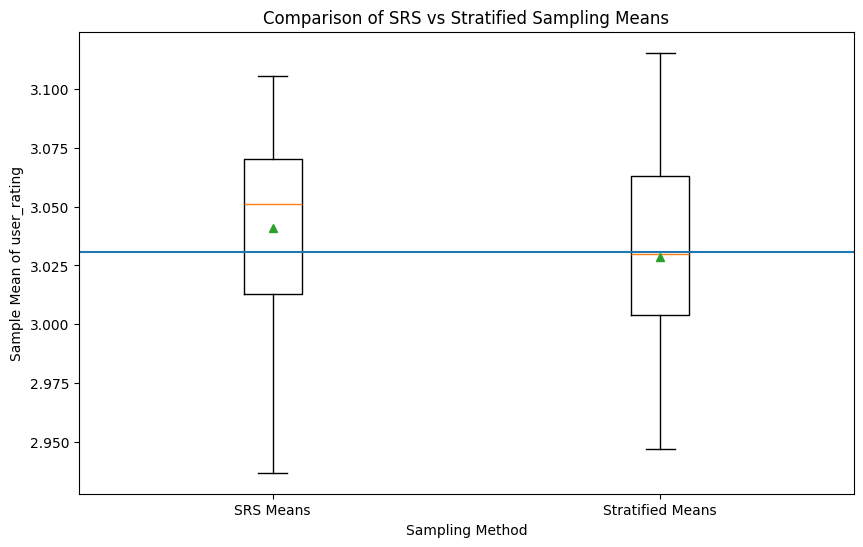


===== RESULTS =====
True Mean: 3.030566037735849
SRS Mean Average: 3.04093
Stratified Mean Average: 3.0287525150905434
SRS Standard Error: 0.04286449696427101
Stratified Standard Error: 0.046666544731486376


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Load dataset
# ----------------------------
df = pd.read_csv("data.csv")

# Ensure correct columns exist
df = df[['genre', 'user_rating']].dropna()
df['user_rating'] = pd.to_numeric(df['user_rating'], errors='coerce')
df = df.dropna()

# ----------------------------
# True population mean
# ----------------------------
true_mean = df['user_rating'].mean()
print("True Population Mean:", true_mean)

# ----------------------------
# Simple Random Sampling (SRS)
# ----------------------------
sample_size = 500      # your sample size
iterations = 20        # number of repeated samples
srs_means = []

for i in range(iterations):
    sample = df.sample(n=sample_size, replace=True)   # IMPORTANT FIX
    srs_means.append(sample['user_rating'].mean())

# ----------------------------
# Stratified Sampling
# ----------------------------
strat_means = []

# Proportions for each stratum
genre_counts = df['genre'].value_counts()
print(genre_counts)
genre_proportions = genre_counts / len(df)
print(genre_proportions)
for i in range(iterations):
    strat_samples = []
    for genre, prop in genre_proportions.items():
        n_genre = int(sample_size * prop)
        part = df[df['genre'] == genre].sample(n=n_genre, replace=True)
        strat_samples.append(part)
    
    final_sample = pd.concat(strat_samples)
    strat_means.append(final_sample['user_rating'].mean())

# ----------------------------
# Visualization
# ----------------------------
plt.figure(figsize=(10, 6))
plt.boxplot([srs_means, strat_means], labels=['SRS Means', 'Stratified Means'], showmeans = True)
plt.axhline(true_mean)
plt.title("Comparison of SRS vs Stratified Sampling Means")
plt.ylabel("Sample Mean of user_rating")
plt.xlabel("Sampling Method")
plt.show()

# ----------------------------
# Print Comparison
# ----------------------------
print("\n===== RESULTS =====")
print("True Mean:", true_mean)
print("SRS Mean Average:", np.mean(srs_means))
print("Stratified Mean Average:", np.mean(strat_means))
print("SRS Standard Error:", np.std(srs_means))
print("Stratified Standard Error:", np.std(strat_means))